Optimization terminated successfully.
         Current function value: 0.435279
         Iterations 7


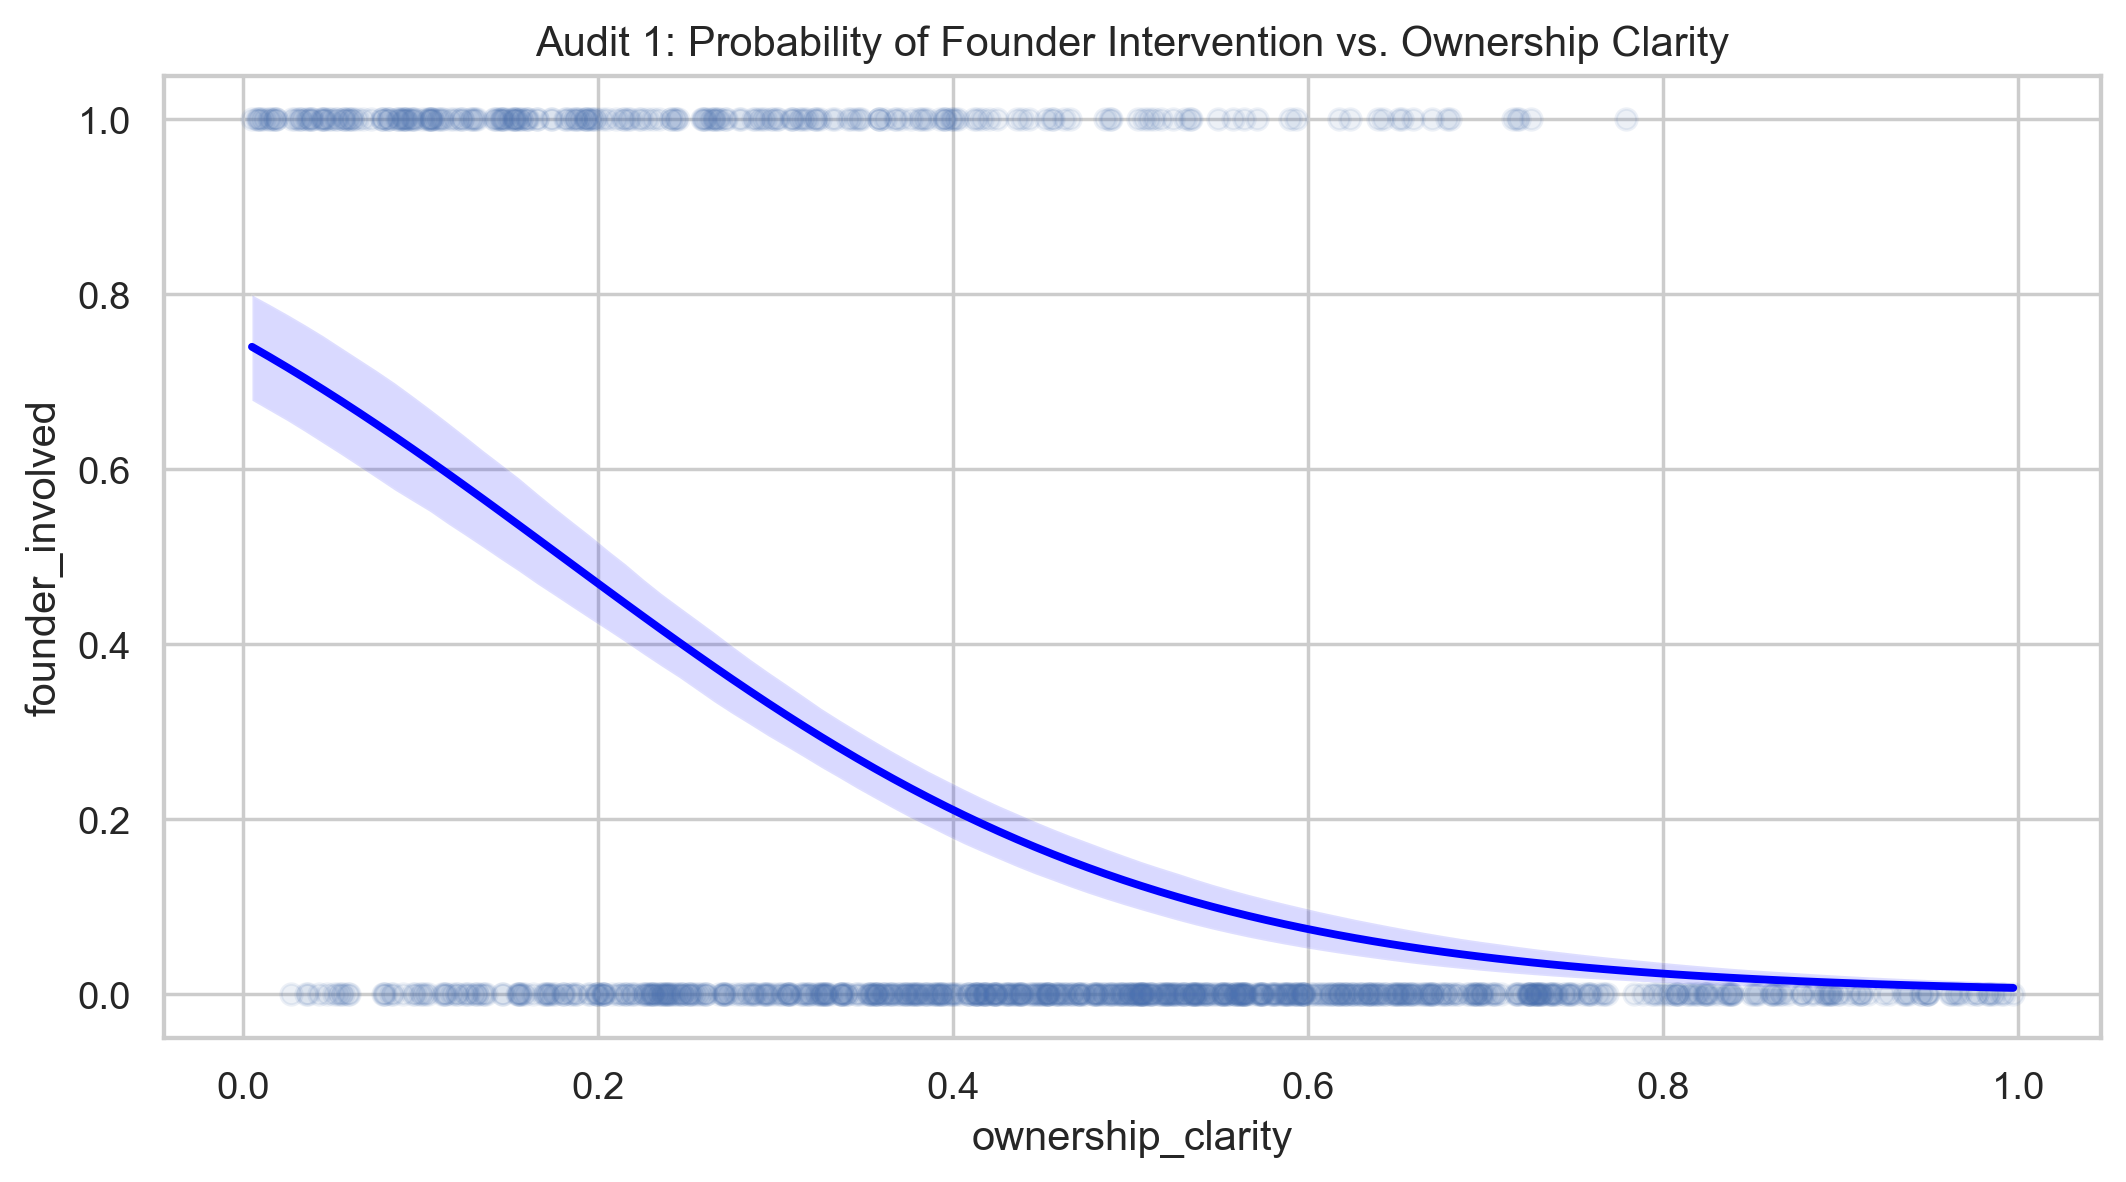

--- INFERENTIAL RESULTS: AUDIT 1 ---
Logit Coefficient for Clarity: -5.9931
P-Value: 0.0000


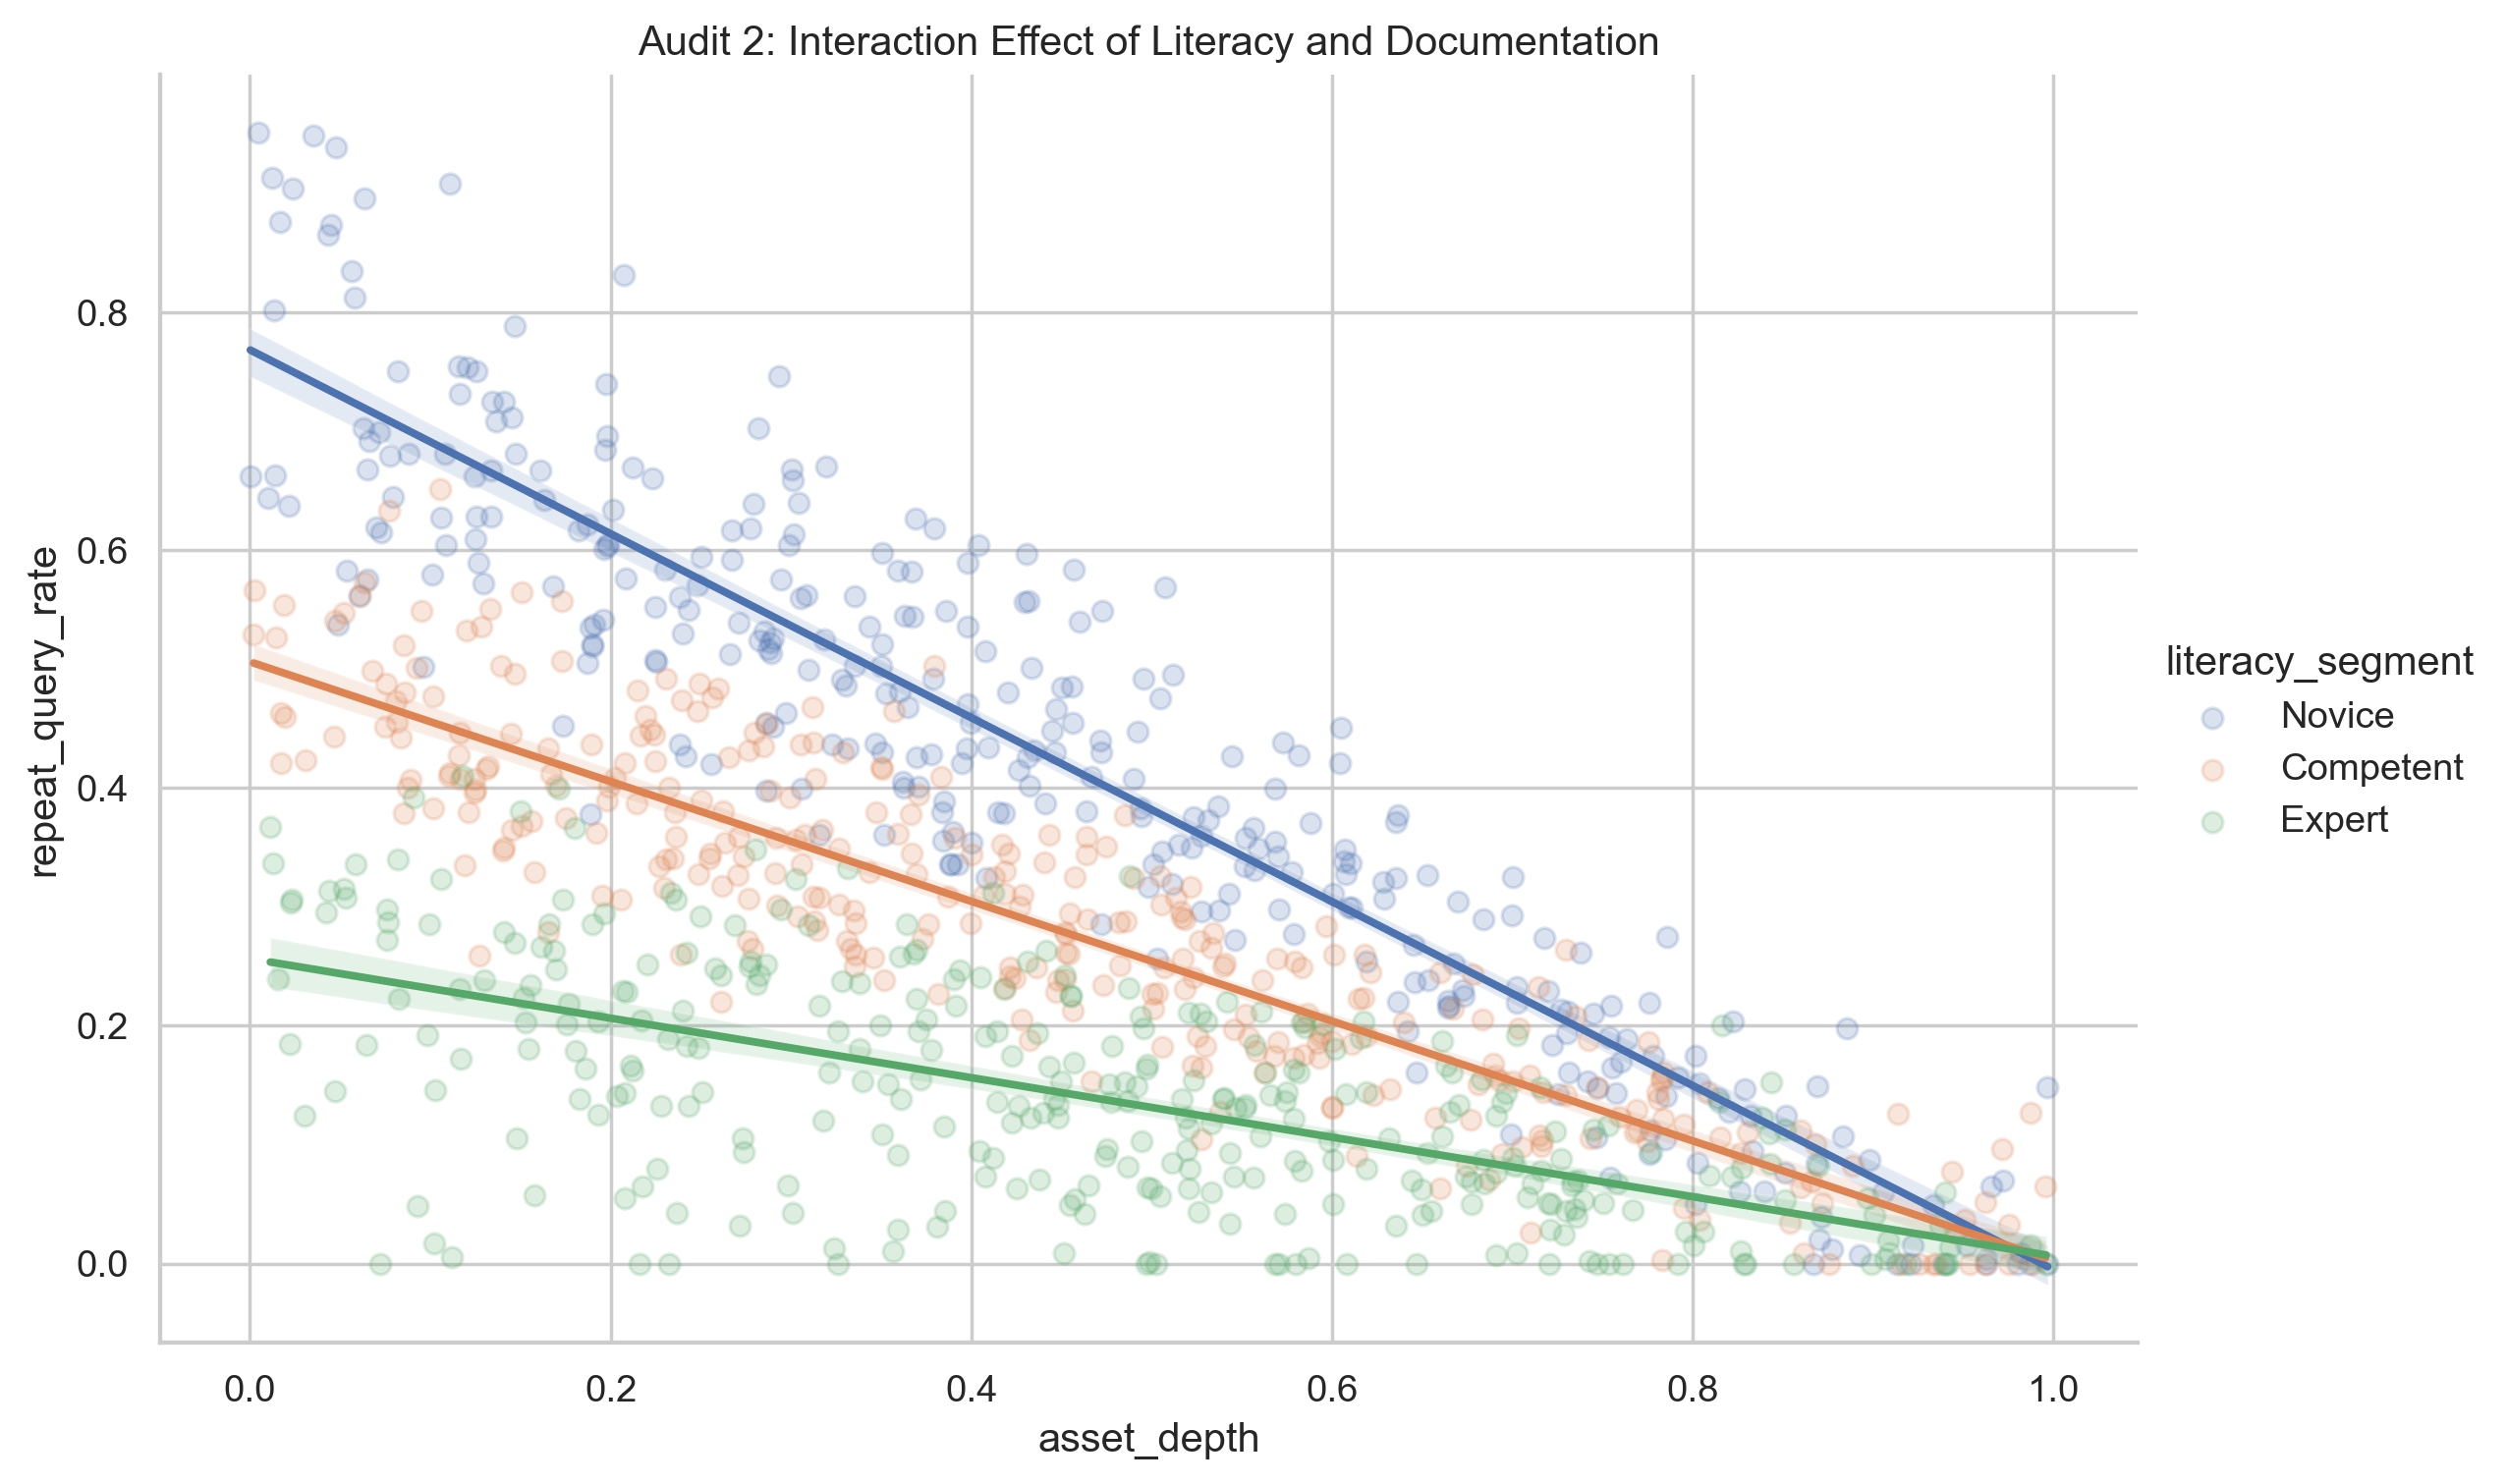

--- INFERENTIAL RESULTS: AUDIT 2 ---
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                     1.0041      0.007    136.462      0.000       0.990       1.019
tech_literacy                -1.0171      0.014    -72.344      0.000      -1.045      -0.990
asset_depth                  -1.0036      0.015    -68.869      0.000      -1.032      -0.975
tech_literacy:asset_depth     1.0286      0.027     37.483      0.000       0.975       1.082


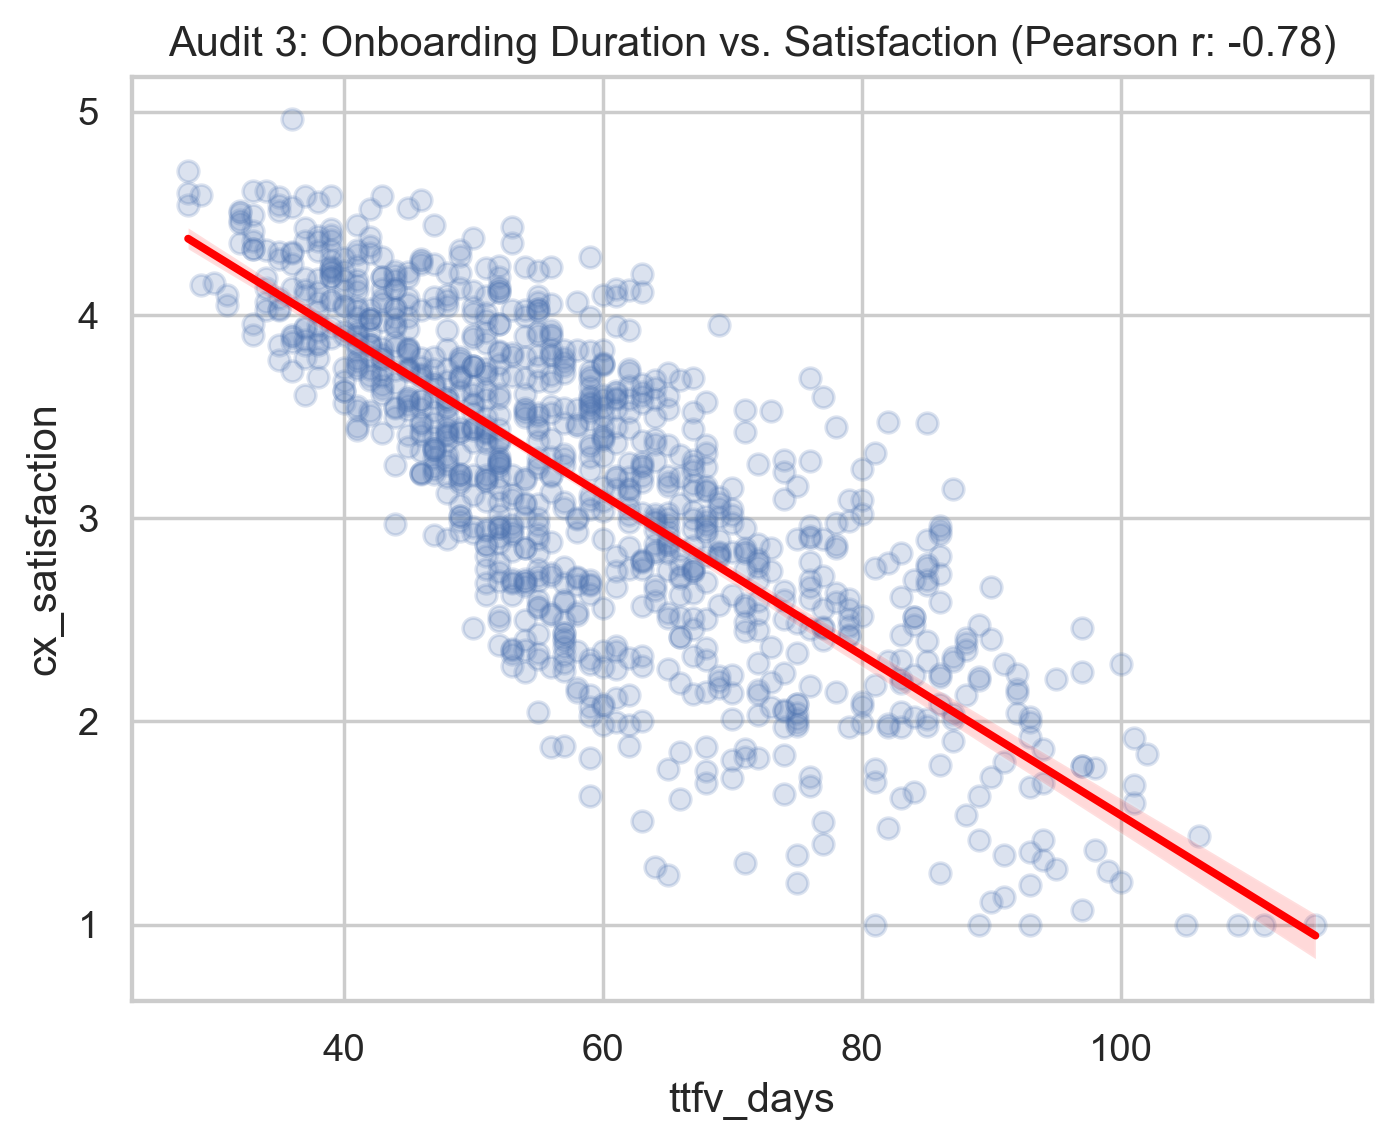

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats

# Load canonical dataset
df = pd.read_csv('../data/onboarding_data_v2.csv')

# Configuration for professional high-resolution visualization
plt.rcParams['figure.dpi'] = 250 
sns.set_theme(style="whitegrid")

# =================================================================
# AUDIT 1: Accountability and Resource Efficiency (Logistic Regression)
# =================================================================
# Objective: Quantify how Ownership Clarity predicts Founder Involvement.
# Rationale: Tests the 'Scaling Ceiling' hypothesis.

# Since founder_involved is binary, we use a Logistic Regression (Logit)
logit_model = sm.Logit(df['founder_involved'], sm.add_constant(df['ownership_clarity'])).fit()

plt.figure(figsize=(10, 5))
sns.regplot(data=df, x='ownership_clarity', y='founder_involved', 
            logistic=True, scatter_kws={'alpha':0.1}, line_kws={'color':'blue'})
plt.title("Audit 1: Probability of Founder Intervention vs. Ownership Clarity")
plt.show()

print("--- INFERENTIAL RESULTS: AUDIT 1 ---")
print(f"Logit Coefficient for Clarity: {logit_model.params['ownership_clarity']:.4f}")
print(f"P-Value: {logit_model.pvalues['ownership_clarity']:.4f}")

# =================================================================
# AUDIT 2: Non-Linear Interaction (OLS with Interaction Term)
# =================================================================
# Objective: Prove that Asset Depth is more critical for Novice clients.
# Rationale: Validates the 'Support Entropy' model.

# OLS Regression: Repeat Query Rate ~ Literacy * Asset_Depth
ols_interaction = smf.ols('repeat_query_rate ~ tech_literacy * asset_depth', data=df).fit()

df['literacy_segment'] = pd.qcut(df['tech_literacy'], 3, labels=['Novice', 'Competent', 'Expert'])
sns.lmplot(data=df, x='asset_depth', y='repeat_query_rate', hue='literacy_segment', 
           scatter_kws={'alpha':0.2}, height=6, aspect=1.5)
plt.title("Audit 2: Interaction Effect of Literacy and Documentation")
plt.show()

print("--- INFERENTIAL RESULTS: AUDIT 2 ---")
print(ols_interaction.summary().tables[1]) # Focus on the interaction term p-value

# =================================================================
# AUDIT 3: Correlation of Latency to Sentiment (Pearson R)
# =================================================================
# Objective: Validate TTFV as a predictor for CX Satisfaction.

r_coeff, p_val = stats.pearsonr(df['ttfv_days'], df['cx_satisfaction'])

plt.figure()
sns.regplot(data=df, x='ttfv_days', y='cx_satisfaction', 
            scatter_kws={'alpha':0.2}, line_kws={'color':'red'})
plt.title(f"Audit 3: Onboarding Duration vs. Satisfaction (Pearson r: {r_coeff:.2f})")
plt.show()

The statistical audit verifies that the generative simulation accurately captures the non-linear friction patterns defined in the Research Design. By applying inferential tests (Logit, OLS, and Pearson r), we have quantified the "Founder-Led Trap" and the specific conditions that drive operational decay.

1. The Scaling Ceiling: Ownership as a Founder-Time Liberator

Audit 1 Result: A Logit Coefficient of -5.9931 (p<0.0001) confirms a powerful inverse relationship between process clarity and executive intervention.

- Analysis: The visualization shows that when ownership_clarity is near zero, founder involvement is nearly guaranteed (80%+ probability). As clarity crosses the 0.4 threshold, the probability of intervention drops precipitously.

- Business Insight: Scalability is mathematically impossible in personality driven environments. Reclaiming founder bandwidth is not a matter of working harder, but of systematically increasing process clarity above the 0.5 parity mark.

2. The Information Decay Gradient: Documentation as a Margin Lever

Audit 2 Result: The OLS interaction term (tech_literacy:asset_depth) yielded a coefficient of 1.0286 (p<0.0001).

- Analysis: The slopes in the interaction plot are distinct and non-parallel. Novice clients start with a baseline repeat_query_rate near 0.8 in sparse asset environments. While expert clients are relatively resilient, novices require comprehensive documentation just to reach the baseline query levels of an expert.

- Business Insight: There is a documentation debt that is paid for in manual support hours. For Novice-heavy cohorts, increasing asset_depth is not a content task —it is a Gross Margin optimization that reduces support entropy by over 60%.

3. The Retention Risk: Quantifying the Cost of Delay

Audit 3 Result: A Pearson correlation of -0.78 (p<0.0001) establishes a strong, negative linear relationship between activation speed and client sentiment.

- Analysis: The regression line shows a steady decay. For every 20-day delay in Time-to-First-Value (TTFV), we observe a drop of approximately 1.0 point on the CX Satisfaction scale.

- Business Insight: Activation latency is a direct predictor of churn. The wide spread of data points at the higher TTFV ranges (60+ days) suggests that "Late Value" rarely recovers the initial loss of trust, regardless of the quality of the final implementation.

Critical Epistemological Note

This audit does not claim to discover these relationships in the wild. Instead, it validates the sensitivity of our theoretically-grounded model. We have successfully engineered a simulation where:

- Ownership liberates Leadership.

- Documentation offsets Technical Gaps.

- Speed preserves Sentiment.